In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation of OT-Impute and other imputation methods
import Utils
import Inject_Missing_Values
import imputers

In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from Inject_Missing_Values import *
# Import your original OTImputer
from imputerss import *
from imputers import *
from Utils import *


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [5]:
data = fetch_openml(name="diabetes", version=1, as_frame=True)
X_full = data.data.copy()

In [6]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB
None


In [7]:
print(X_full)

     preg  plas  pres  skin  insu  mass   pedi  age
0       6   148    72    35     0  33.6  0.627   50
1       1    85    66    29     0  26.6  0.351   31
2       8   183    64     0     0  23.3  0.672   32
3       1    89    66    23    94  28.1  0.167   21
4       0   137    40    35   168  43.1  2.288   33
..    ...   ...   ...   ...   ...   ...    ...  ...
763    10   101    76    48   180  32.9  0.171   63
764     2   122    70    27     0  36.8  0.340   27
765     5   121    72    23   112  26.2  0.245   30
766     1   126    60     0     0  30.1  0.349   47
767     1    93    70    31     0  30.4  0.315   23

[768 rows x 8 columns]


In [8]:
#scaler = MinMaxScaler() #data [0,1]
#X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

scaler = StandardScaler()
X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

In [9]:
print(X_full)

         preg      plas      pres      skin      insu      mass      pedi  \
0    0.639947  0.848324  0.149641  0.907270 -0.692891  0.204013  0.468492   
1   -0.844885 -1.123396 -0.160546  0.530902 -0.692891 -0.684422 -0.365061   
2    1.233880  1.943724 -0.263941 -1.288212 -0.692891 -1.103255  0.604397   
3   -0.844885 -0.998208 -0.160546  0.154533  0.123302 -0.494043 -0.920763   
4   -1.141852  0.504055 -1.504687  0.907270  0.765836  1.409746  5.484909   
..        ...       ...       ...       ...       ...       ...       ...   
763  1.827813 -0.622642  0.356432  1.722735  0.870031  0.115169 -0.908682   
764 -0.547919  0.034598  0.046245  0.405445 -0.692891  0.610154 -0.398282   
765  0.342981  0.003301  0.149641  0.154533  0.279594 -0.735190 -0.685193   
766 -0.844885  0.159787 -0.470732 -1.288212 -0.692891 -0.240205 -0.371101   
767 -0.844885 -0.873019  0.046245  0.656358 -0.692891 -0.202129 -0.473785   

          age  
0    1.425995  
1   -0.190672  
2   -0.105584  
3   -1.0415

Storing the clean data as Ground Truth

In [10]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [11]:
GroundTruth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    float64
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   insu    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    float64
dtypes: float64(8)
memory usage: 48.1 KB


Converting GroundTruth to tensor

In [12]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [13]:
GroundTruth.nunique()

preg     17
plas    136
pres     47
skin     51
insu    186
mass    248
pedi    517
age      52
dtype: int64

Dependecies for MAR & MNAR

In [14]:
mean_age = GroundTruth["age"].mean()
mean_preg = GroundTruth["preg"].mean()
mean_plas = GroundTruth["plas"].mean()
median_pres = GroundTruth["pres"].median()
median_skin = GroundTruth["skin"].median()
mean_insu = GroundTruth["insu"].mean()
mean_mass = GroundTruth["mass"].mean()
median_pedi = GroundTruth["pedi"].median()

dependencies_mar = {
    "preg": {
        "influencers": ["plas"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["plas"] >= mean_plas else 0.1
    },
    "plas": {
        "influencers": ["mass"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["mass"] <= mean_mass else 0.1
    },
    "pres": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] >= mean_age else 0.1
    },
    "skin": {
        "influencers": ["pres"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pres"] <= median_pres else 0.1
    },
    "insu": {
        "influencers": ["preg"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["preg"] >= mean_preg else 0.1
    },
    "mass": {
        "influencers": ["pedi"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pedi"] >= median_pedi else 0.1
    },
    "pedi": {
        "influencers": ["skin"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["skin"] <= median_skin else 0.1
    },
    "age": {
        "influencers": ["insu"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["insu"] >= mean_insu else 0.1
    }
}


In [15]:
mean_preg = GroundTruth["preg"].mean()
mean_plas = GroundTruth["plas"].mean()
median_pres = GroundTruth["pres"].median()
median_skin = GroundTruth["skin"].median()
mean_insu = GroundTruth["insu"].mean()
mean_mass = GroundTruth["mass"].mean()
median_pedi = GroundTruth["pedi"].median()
mean_age = GroundTruth["age"].mean()


dependencies_mnar = {
    "preg": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["preg"] >= mean_preg else 0.1
    },
    "plas": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["plas"] < mean_plas else 0.1
    },
    "pres": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pres"] <= median_pres else 0.1
    },
    "skin": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["skin"] >= median_skin else 0.1
    },
    "insu": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["insu"] > mean_insu else 0.1
    },
    "mass": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["mass"] <= mean_mass else 0.1
    },
    "pedi": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pedi"] >= median_pedi else 0.1
    },
    "age": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] > mean_age else 0.1
    }
}


### Bayesian Neural Network

In [16]:

import torchbnn as bnn
class BayesianRegressionHead(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.mean_head = bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=input_dim, out_features=1)
        self.log_var_head = bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=input_dim, out_features=1)

    def forward(self, x):
        mean = self.mean_head(x)
        log_var = self.log_var_head(x)
        return mean, log_var

'''''''''''
import torch
import torch.nn as nn
import torchbnn as bnn

class BayesianRegressionHead(nn.Module):
    def __init__(self, input_dim, init_logvar=-1.0):
        super().__init__()
        # Shared feature extraction
        self.shared_layer = bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, 
                                          in_features=input_dim, 
                                          out_features=64)
        
        # Mean and variance heads
        self.mean_head = nn.Linear(64, 1)
        self.logvar_head = nn.Linear(64, 1)
        
        # Initialize variance prediction
        self.logvar_head.weight.data.normal_(mean=init_logvar, std=0.1)
        self.logvar_head.bias.data.constant_(init_logvar)

    def forward(self, x):
        # Shared features
        features = torch.relu(self.shared_layer(x))
        
        # Predictions
        mean = self.mean_head(features)
        log_var = self.logvar_head(features).clamp(min=-10, max=10)  # Numerical stability
        
        return mean.squeeze(-1), log_var.squeeze(-1)
''''''''' 

"''\nimport torch\nimport torch.nn as nn\nimport torchbnn as bnn\n\nclass BayesianRegressionHead(nn.Module):\n    def __init__(self, input_dim, init_logvar=-1.0):\n        super().__init__()\n        # Shared feature extraction\n        self.shared_layer = bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, \n                                          in_features=input_dim, \n                                          out_features=64)\n        \n        # Mean and variance heads\n        self.mean_head = nn.Linear(64, 1)\n        self.logvar_head = nn.Linear(64, 1)\n        \n        # Initialize variance prediction\n        self.logvar_head.weight.data.normal_(mean=init_logvar, std=0.1)\n        self.logvar_head.bias.data.constant_(init_logvar)\n\n    def forward(self, x):\n        # Shared features\n        features = torch.relu(self.shared_layer(x))\n        \n        # Predictions\n        mean = self.mean_head(features)\n        log_var = self.logvar_head(features).clamp(min=-10, max=10)  

### MLP

In [17]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

        # Additional hidden layer (optional for capacity)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        
        # Two output heads: mean and log variance
        self.fc_mu = nn.Linear(hidden_dim, output_dim)
        self.fc_logvar = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h = self.relu(self.fc1(x))
        h = self.dropout(h)
        h = self.relu(self.fc2(h))
        h = self.dropout(h)
        
        mu = self.fc_mu(h)
        
        log_var = self.fc_logvar(h)
        log_var = torch.clamp(log_var, min=-5, max=2)  # clip to avoid extreme σ²

        return mu, log_var



In [18]:
class LinearRR(nn.Module):  # or AleatoricLinear
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.fc_mu = nn.Linear(input_dim, output_dim)
        self.fc_logvar = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        mu = self.fc_mu(x)
        log_var = self.fc_logvar(x)
        log_var = torch.clamp(log_var, min=-5, max=2)  # for stability
        return mu, log_var


In [19]:
def calibration_curve(pred, true, var, k=20):
    pred = pred.detach().cpu().numpy()
    true = true.detach().cpu().numpy()
    var = var.detach().cpu().numpy()

    error = (pred - true) ** 2
    sorted_indices = np.argsort(var)

    pred = pred[sorted_indices]
    true = true[sorted_indices]
    var = var[sorted_indices]
    error = error[sorted_indices]

    n = len(pred)
    bin_size = n // k

    avg_uncertainty = []
    avg_error = []
    bin_sizes = []

    for i in range(k):
        start = i * bin_size
        end = (i + 1) * bin_size if i != k - 1 else n

        bin_var = var[start:end]
        bin_error = error[start:end]

        avg_uncertainty.append(np.mean(bin_var))
        avg_error.append(np.mean(bin_error))
        bin_sizes.append(end - start)

    
    ece = 0.0
    for i in range(k):
            weight = bin_sizes[i] / n
            gap = abs(avg_uncertainty[i] - avg_error[i])
            ece += weight * gap
    return avg_uncertainty, avg_error, ece
    


In [20]:
import numpy as np
import torch

def calibration_curve_quantile(pred, true, var, k=20):
    """
    Compute a calibration curve using quantile-based binning.

    Args:
        pred (Tensor): Predicted mean values (shape: [n_samples])
        true (Tensor): Ground truth values (shape: [n_samples])
        var (Tensor): Predicted variance values (shape: [n_samples])
        k (int): Number of quantile bins

    Returns:
        avg_uncertainty (list): Mean predicted variance per bin
        avg_error (list): Mean squared error per bin
        ece (float): Expected Calibration Error
    """
    # Convert to numpy arrays
    pred = pred.detach().cpu().numpy().flatten()
    true = true.detach().cpu().numpy().flatten()
    var = var.detach().cpu().numpy().flatten()

    assert pred.shape == true.shape == var.shape, "Shapes of pred, true, and var must match"

    error = (pred - true) ** 2
    n = len(pred)

    # Compute quantile bins
    quantiles = np.percentile(var, np.linspace(0, 100, k + 1))
    avg_uncertainty = []
    avg_error = []
    bin_sizes = []

    for i in range(k):
        low = quantiles[i]
        high = quantiles[i + 1]

        if i == k - 1:
            mask = (var >= low) & (var <= high)  # include right edge in last bin
        else:
            mask = (var >= low) & (var < high)

        bin_var = var[mask]
        bin_error = error[mask]
        print(f"Bin {i}: size={len(bin_var)}, avg_uncertainty={np.mean(bin_var) if len(bin_var) > 0 else float('nan'):.4f}, avg_error={np.mean(bin_error) if len(bin_error) > 0 else float('nan'):.4f}")
        if len(bin_var) == 0:
            continue  # skip empty bins

        avg_uncertainty.append(np.mean(bin_var))
        avg_error.append(np.mean(bin_error))
        bin_sizes.append(len(bin_var))

    # Compute ECE
    ece = 0.0
    for u, e, size in zip(avg_uncertainty, avg_error, bin_sizes):
        weight = size / n
        gap = abs(u - e)
        ece += weight * gap

    return avg_uncertainty, avg_error, ece


Bayesian Model........
torch.Size([768, 8])
torch.Size([15, 768, 8])
torch.Size([1843])
torch.Size([1843])
Bin 0: size=93, avg_uncertainty=0.0524, avg_error=0.3957
Bin 1: size=92, avg_uncertainty=0.0686, avg_error=0.4657
Bin 2: size=92, avg_uncertainty=0.0792, avg_error=0.2886
Bin 3: size=92, avg_uncertainty=0.0894, avg_error=0.7739
Bin 4: size=92, avg_uncertainty=0.0996, avg_error=0.4607
Bin 5: size=92, avg_uncertainty=0.1096, avg_error=0.5875
Bin 6: size=92, avg_uncertainty=0.1185, avg_error=0.5214
Bin 7: size=92, avg_uncertainty=0.1273, avg_error=0.7870
Bin 8: size=92, avg_uncertainty=0.1358, avg_error=0.4306
Bin 9: size=92, avg_uncertainty=0.1449, avg_error=0.8267
Bin 10: size=93, avg_uncertainty=0.1554, avg_error=0.7503
Bin 11: size=92, avg_uncertainty=0.1662, avg_error=0.6929
Bin 12: size=92, avg_uncertainty=0.1756, avg_error=0.8072
Bin 13: size=92, avg_uncertainty=0.1853, avg_error=0.9062
Bin 14: size=92, avg_uncertainty=0.1955, avg_error=1.1878
Bin 15: size=92, avg_uncertainty=

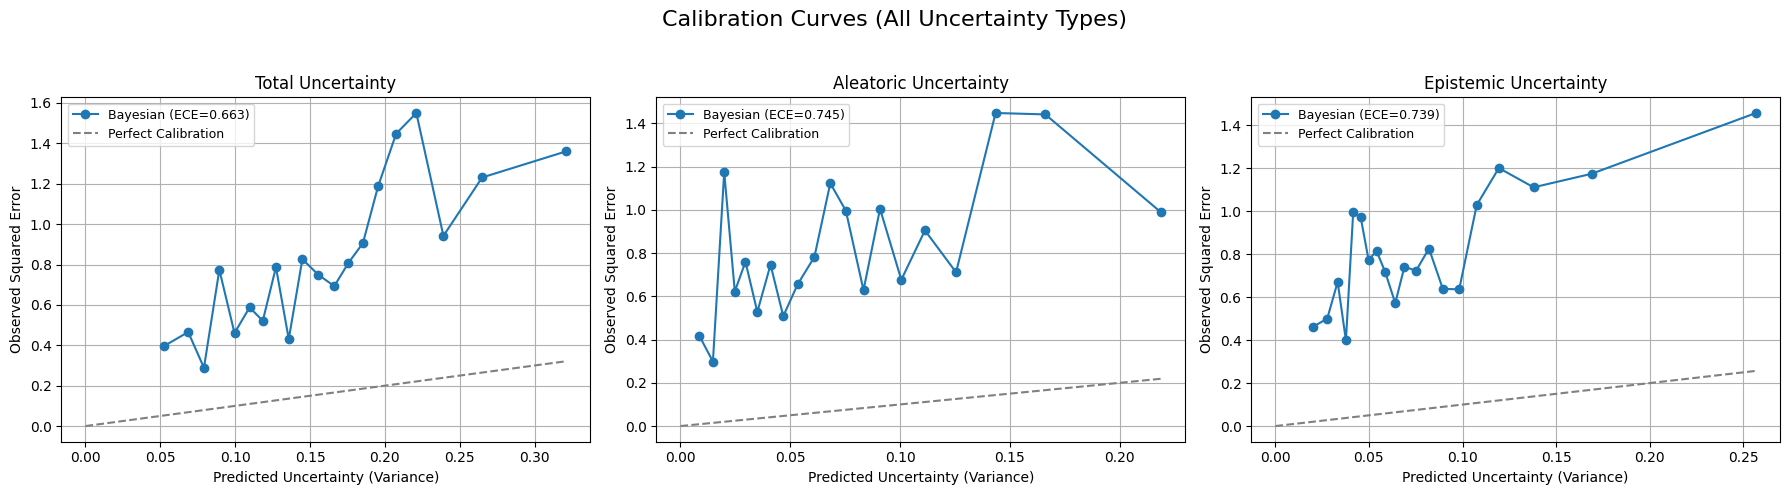

In [21]:

    
results_mcar = []
calib_results_mcar = []
missing_rate = 30

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
  
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 15 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed

log_var_runs=[]
   
    #Bayesian Model
print("Bayesian Model........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
variance_tensor = []
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
            models_bnn[i] = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=d_, out_features=2 * d_),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2 * d_, out_features=d_),
            nn.ReLU(),
            BayesianRegressionHead(d_)
            ).double()
        
        #Create the imputer
    rr_imputer_bnn = RRimputer(models_bnn,sample=True) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn, variance_bnn, uncertaity_log_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    variance_tensor.append(variance_bnn)  # sum across runs
print(variance_bnn.shape)


#variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
variance_tensor_bnn = torch.stack(variance_tensor)
print(variance_tensor_bnn.shape)
aleatoric_uncertainty_bnn  = variance_tensor_bnn.mean(dim=0)
aleatoric_uncertainty_bnn = aleatoric_uncertainty_bnn[mask]

mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
#aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2
print(aleatoric_uncertainty_bnn.shape)
print(epistemic_uncertainty_bnn_variance.shape)

        # combine uncertainties
total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()


total_calib_uncert_bnn, total_calib_error_bnn, total_calib_ece_bnn = calibration_curve_quantile(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=total_uncertainty_bnn

)

aleatoric_calib_uncert_bnn, aleatoric_calib_error_bnn, aleatoric_calib_ece_bnn = calibration_curve_quantile(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=aleatoric_uncertainty_bnn
)

epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = calibration_curve_quantile(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"Bayesian",
    "missing_rate": missing_rate,
    "total_calib_uncertainty": total_calib_uncert_bnn,
    "total_calib_error": total_calib_error_bnn,
    "total_calib_ece": total_calib_ece_bnn,
    "aleatoric_calib_uncertainty": aleatoric_calib_uncert_bnn,
    "aleatoric_calib_error": aleatoric_calib_error_bnn,
    "aleatoric_calib_ece": aleatoric_calib_ece_bnn,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"Bayesian",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "aleatoric_uncertainty": aleatoric_uncertainty_bnn.mean().item(),
            "total_uncertainty": total_uncertainty_bnn_std.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
            "uncertaity_log":uncertaity_log_bnn
        })

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Experiment_mcar_comparision_results30_quantile.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Experiment_mcar_calib_results30_quantile.csv", index=False)



import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Experiment_mcar_calib_results30_quantile.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
#plt.savefig(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Housing_mcar_comparision_sampled_results30.png", dpi=300)
plt.show()


### MCAR

In [31]:

results_mcar = []
calib_results_mcar = []
missing_rate = 30

generator_mcar = Inject_Missing_Values() #missing value generating
miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.double) #converting the missing matrix to tensor
   
n, d = miss_mcar.shape #shape of missing matrix

n_runs = 1 # will run n times

mask = torch.isnan(X_missing_tensor) # creating missing mask

d_ = d - 1 #the number of models needed


   
  
print("Basic")
print("MLP........")
imputed_values_bnn = []
variance_tensor_bnn = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models_bnn = {}
    for i in range(d):
        models_bnn[i] = nn.Sequential(nn.Linear(d_, 2 * d_),
                                nn.ReLU(),
                                nn.Linear(2 * d_, d_),
                                nn.ReLU(),
                                nn.Linear(d_, 1)).double()
        #Create the imputer
    rr_imputer_bnn = RRimputer_b(models_bnn) #passing the bnn models
    imputed_bnn, maes_bnn, rmse_bnn = rr_imputer_bnn.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values_bnn.append(imputed_bnn.unsqueeze(0))
    #variance_tensor_bnn += variance_bnn  # sum across runs

#variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor_bnn = torch.cat(imputed_values_bnn, dim=0)  # [n_runs, n, d]
mean_impute_bnn = imputed_tensor_bnn.mean(dim=0)
std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
#aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty_bnn = std_impute_bnn[mask]
epistemic_uncertainty_bnn_variance = epistemic_uncertainty_bnn** 2

        # combine uncertainties
#total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
#total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae_bnn = torch.abs(mean_impute_bnn[mask] - GroundTruth_tensor[mask]).mean().item()




epistemic_calib_uncert_bnn, epistemic_calib_error_bnn, epistemic_calib_ece_bnn = calibration_curve(
    pred=mean_impute_bnn[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_bnn_variance
)


calib_results_mcar.append({
    "method":"MLP_vanilla",
    "missing_rate": missing_rate,
    "epistemic_calib_uncertainty": epistemic_calib_uncert_bnn,
    "epistemic_calib_error": epistemic_calib_error_bnn,
    "epistemic_calib_ece": epistemic_calib_ece_bnn
})


results_mcar.append({
           
            "method":"MLP_vanilla",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty_bnn.mean().item(),
            "mae": mae_bnn,
            "maes":maes_bnn,
          
        })

 





print("Updated")
print("MLP........")
imputed_values = []
variance_tensor = torch.zeros_like(X_missing_tensor) 
for run in range(n_runs):

    torch.manual_seed(run)

        #creating the bnn models
    models = {}
    for i in range(d):
        models[i] = MLP(input_dim=d_, hidden_dim=64, output_dim=1).double()
        #Create the imputer
    rr_imputer = RRimputer(models) #passing the bnn models
    imputed, maes, rmse, variance, uncertainty_log = rr_imputer.fit_transform(X_missing_tensor,X_true=GroundTruth_tensor)
    imputed_values.append(imputed_bnn.unsqueeze(0))
    #variance_tensor_bnn += variance_bnn  # sum across runs

#variance_tensor_bnn /= n_runs  # average aleatoric uncertainty
imputed_tensor = torch.cat(imputed_values, dim=0)  # [n_runs, n, d]
mean_impute = imputed_tensor_bnn.mean(dim=0)
std_impute = imputed_tensor.std(dim=0)  # epistemic uncertainty
        
        # Apply mask to get only missing entries
#aleatoric_uncertainty_bnn = variance_tensor_bnn[mask]  # [0.01, 0.04]
epistemic_uncertainty= std_impute[mask]
epistemic_uncertainty_variance = epistemic_uncertainty** 2

        # combine uncertainties
#total_uncertainty_bnn = (aleatoric_uncertainty_bnn + epistemic_uncertainty_bnn** 2)       
#total_uncertainty_bnn_std = torch.sqrt(total_uncertainty_bnn)
mae = torch.abs(mean_impute[mask] - GroundTruth_tensor[mask]).mean().item()




epistemic_calib_uncert, epistemic_calib_error, epistemic_calib_ece = calibration_curve(
    pred=mean_impute[mask],
    true=GroundTruth_tensor[mask],
    var=epistemic_uncertainty_variance
)


calib_results_mcar.append({
    "method":"MLP_updated",
    "missing_rate": missing_rate,
    "epistemic_calib_uncertainty": epistemic_calib_uncert,
    "epistemic_calib_error": epistemic_calib_error,
    "epistemic_calib_ece": epistemic_calib_ece
})


results_mcar.append({
           
            "method":"MLP_updated",
            "missing_rate": missing_rate,
            "epistemic_uncertainty":  epistemic_uncertainty.mean().item(),
            "mae": mae,
            "maes":maes,
          
        })


df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Experiment_result.csv", index=False)
df_results_calib = pd.DataFrame(calib_results_mcar)
df_results_calib.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Experiment_mcar_calib_results30.csv", index=False)


Basic
MLP........


C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\imputerss.py:361: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  print("mean",mean.grad)


mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None
mean None


C:\Users\zhossai3\AppData\Local\Temp\ipykernel_13272\1201680063.py:45: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  std_impute_bnn = imputed_tensor_bnn.std(dim=0)  # epistemic uncertainty
C:\Users\zhossai3\AppData\Local\Temp\ipykernel_13272\1201680063.py:113: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  std_impute = imputed_tensor.std(dim=0)  # epistemic uncertainty


Skipping MLP_vanilla for epistemic: malformed node or string on line 1: <ast.Call object at 0x0000023B99077110>
Skipping MLP_updated for epistemic: malformed node or string on line 1: <ast.Call object at 0x0000023B990516D0>


ValueError: malformed node or string on line 1: <ast.Call object at 0x0000023B99079790>

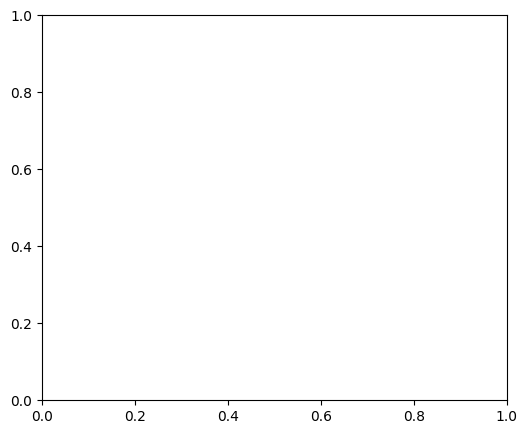

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Experiment_mcar_calib_results30.csv")

# Define uncertainty types to plot
uncertainty_types = ["epistemic"]

# Set up subplots
fig, axes = plt.subplots(1, len(uncertainty_types), figsize=(6 * len(uncertainty_types), 5))

if len(uncertainty_types) == 1:
    axes = [axes]  # Make iterable if only one axis

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Safely parse list strings to actual Python lists
        try:
            avg_uncert = ast.literal_eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
            avg_error = ast.literal_eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])
            ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])

            # Plot
            label = f"{method} (ECE={ece:.3f})"
            ax.plot(avg_uncert, avg_error, marker='o', label=label)

        except (ValueError, SyntaxError) as e:
            print(f"Skipping {method} for {uncertainty_type}: {e}")

    # Add perfect calibration line
    max_val = max([
        max(ast.literal_eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
        if isinstance(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"], str)
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


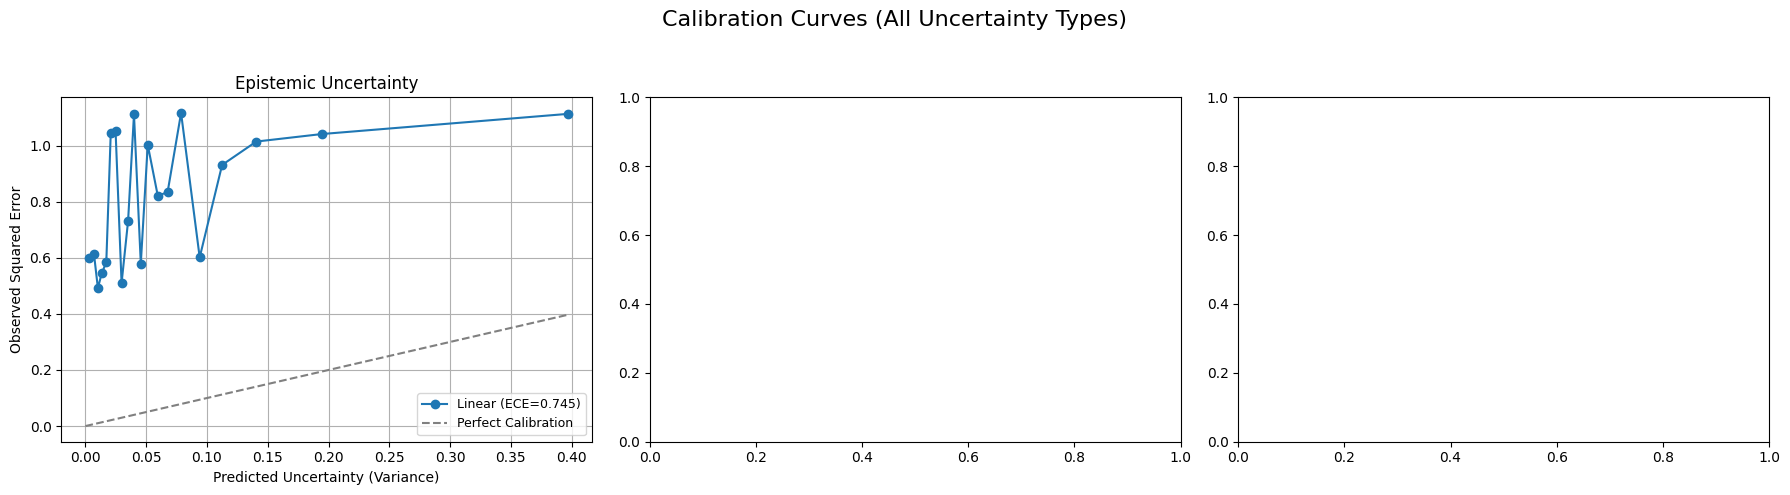

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Experiment2_mcar_calib_results30.csv")

# Uncertainty types to plot
uncertainty_types = ["epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
#plt.savefig(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_calibration_curves_all_types.png", dpi=300)
plt.show()



### Visualization

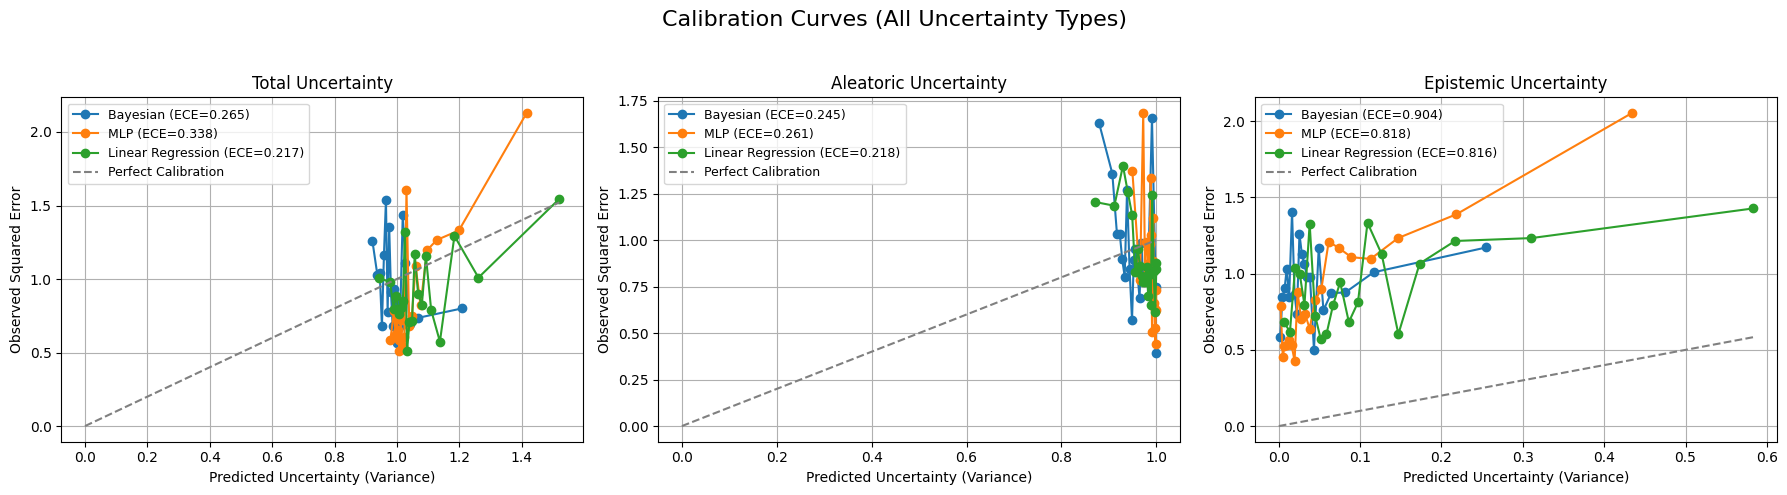

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_calib_results30.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the plot
plt.savefig(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_calibration_curves_all_types.png", dpi=300)
plt.show()


C:\Users\zhossai3\AppData\Local\Temp\ipykernel_1876\379660983.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 2, 0.05])


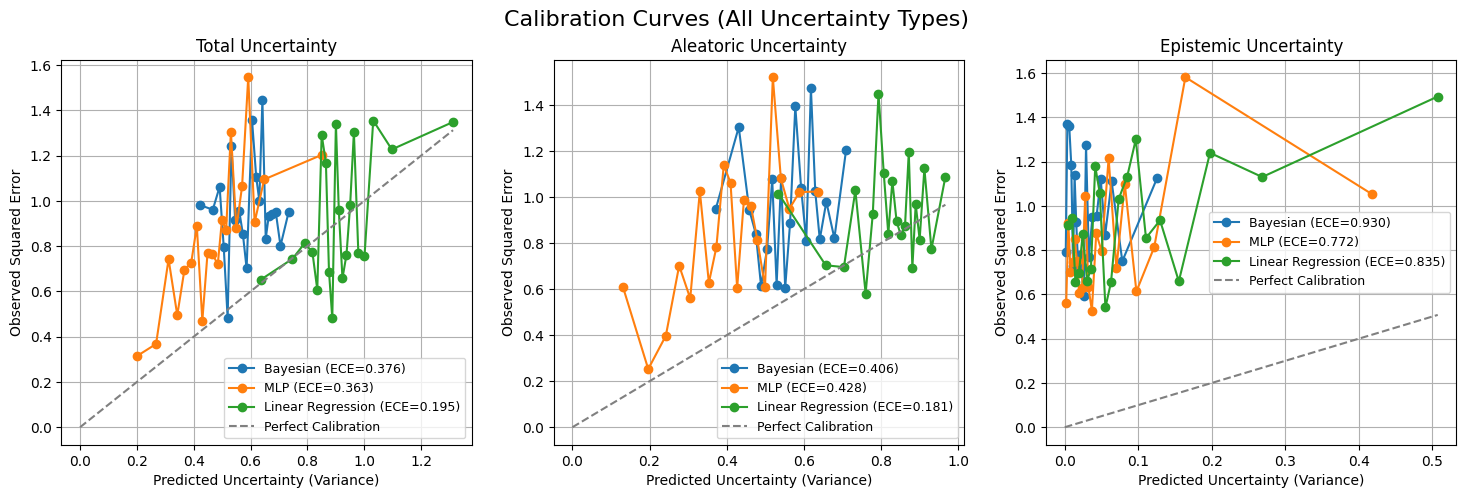

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load calibration results
calib_df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_calib_sampled_results30.csv")

# Uncertainty types to plot
uncertainty_types = ["total", "aleatoric", "epistemic"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, uncertainty_type in enumerate(uncertainty_types):
    ax = axes[col_idx]

    for i in range(len(calib_df)):
        method = calib_df.loc[i, "method"]

        # Add ECE to the legend label
        ece = float(calib_df.loc[i, f"{uncertainty_type}_calib_ece"])
        label = f"{method} (ECE={ece:.3f})"

        # Use eval() to parse stringified list values
        avg_uncert = eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"])
        avg_error = eval(calib_df.loc[i, f"{uncertainty_type}_calib_error"])

        # Plot
        ax.plot(avg_uncert, avg_error, marker='o', label=label)

    # Perfect calibration line
    max_val = max([
        max(eval(calib_df.loc[i, f"{uncertainty_type}_calib_uncertainty"]))
        for i in range(len(calib_df))
    ])
    ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label="Perfect Calibration")

    ax.set_xlabel("Predicted Uncertainty (Variance)")
    ax.set_ylabel("Observed Squared Error")
    ax.set_title(f"{uncertainty_type.capitalize()} Uncertainty")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves (All Uncertainty Types)", fontsize=16)
plt.tight_layout(rect=[0, 0, 2, 0.05])

# Save the plot
plt.savefig(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_mcar_comparision_sampled_results30.png", dpi=300)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

class VAEAC(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=32):
        super(VAEAC, self).__init__()
        self.input_dim = input_dim
        
        # Encoder: input = x * mask + mask
        self.encoder_fc1 = nn.Linear(input_dim * 2, hidden_dim)
        self.encoder_fc21 = nn.Linear(hidden_dim, latent_dim)  # mu
        self.encoder_fc22 = nn.Linear(hidden_dim, latent_dim)  # logvar

        # Decoder: input = z + observed entries
        self.decoder_fc1 = nn.Linear(latent_dim + input_dim, hidden_dim)
        self.decoder_fc2 = nn.Linear(hidden_dim, input_dim)

    # Encoder: takes x and mask
    def encode(self, x, mask):
        h = F.relu(self.encoder_fc1(torch.cat([x * mask, mask], dim=1)))
        mu = self.encoder_fc21(h)
        logvar = self.encoder_fc22(h)
        return mu, logvar

    # Reparameterization trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar) + 1e-6
        eps = torch.randn_like(std)
        return mu + eps * std

    # Decoder: conditioned on observed entries
    def decode(self, z, x_observed_masked):
        h = F.relu(self.decoder_fc1(torch.cat([z, x_observed_masked], dim=1)))
        return torch.sigmoid(self.decoder_fc2(h))

    def forward(self, x, mask):
        mu, logvar = self.encode(x, mask)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, x * mask)
        return recon, mu, logvar

    # VAE loss: reconstruction on observed entries + KL
    def vae_loss(self, x, recon_x, mu, logvar, mask):
        recon_loss = ((x - recon_x) ** 2 * mask).sum() / mask.sum()
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
        return recon_loss + kl_div

    # Training function
    def train_vae(self, data_with_missing, mask, epochs=100, batch_size=32, lr=1e-3, beta=1.0):
        data_filled = data_with_missing.copy()
        col_means = data_with_missing.mean(axis=0)
        data_filled = data_filled.fillna(col_means)

        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        dataset = TensorDataset(
            torch.tensor(data_filled.values, dtype=torch.float32),
            torch.tensor(mask.values, dtype=torch.float32)
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        self.train()
        for epoch in range(epochs):
            for x_batch, m_batch in loader:
                optimizer.zero_grad()
                recon_batch, mu, logvar = self(x_batch, m_batch)
                loss = self.vae_loss(x_batch, recon_batch, mu, logvar, m_batch) * beta
                loss.backward()
                optimizer.step()

        # Return reconstruction, mu, std for reference
        self.eval()
        with torch.no_grad():
            x_tensor = torch.tensor(data_filled.values, dtype=torch.float32)
            mask_tensor = torch.tensor(mask.values, dtype=torch.float32)
            recon, mu, logvar = self(x_tensor, mask_tensor)
            std = torch.exp(0.5 * logvar)

        return recon.numpy(), mu.numpy(), std.numpy()

    # Imputation with multiple samples: returns mean + std for missing entries
    def vae_with_std(self, data_with_missing, mask, num_samples=100):
        self.eval()
        data_filled = data_with_missing.copy()
        col_means = data_with_missing.mean(axis=0)
        data_filled = data_filled.fillna(col_means)

        x_tensor = torch.tensor(data_filled.values, dtype=torch.float32)
        mask_tensor = torch.tensor(mask.values, dtype=torch.float32)

        all_recons = []
        with torch.no_grad():
            mu, logvar = self.encode(x_tensor, mask_tensor)
            for _ in range(num_samples):
                z = self.reparameterize(mu, logvar)
                recon = self.decode(z, x_tensor * mask_tensor)
                all_recons.append(recon.unsqueeze(0))  # (1, N, D)

        all_recons = torch.cat(all_recons, dim=0)      # (S, N, D)
        mean_recon = all_recons.mean(dim=0).numpy()    # convert to NumPy
        aleatoric_std = all_recons.std(dim=0).numpy() 

        return mean_recon, aleatoric_std





In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

class VAEAC(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, latent_dim=64, num_layers=3):
        super(VAEAC, self).__init__()
        self.input_dim = input_dim
        
        # Enhanced encoder with multiple layers
        encoder_layers = []
        current_dim = input_dim * 2
        for _ in range(num_layers):
            encoder_layers.extend([
                nn.Linear(current_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.2),
            
            ])
            current_dim = hidden_dim
        
        self.encoder = nn.Sequential(*encoder_layers)
        self.encoder_fc21 = nn.Linear(hidden_dim, latent_dim)  # mu
        self.encoder_fc22 = nn.Linear(hidden_dim, latent_dim)  # logvar

        # Enhanced decoder with multiple layers
        decoder_layers = []
        current_dim = latent_dim + input_dim
        for _ in range(num_layers):
            decoder_layers.extend([
                nn.Linear(current_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.LeakyReLU(0.2),
              
            ])
            current_dim = hidden_dim
        
        self.decoder = nn.Sequential(*decoder_layers)
        self.decoder_fc2 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x, mask):
        # Concatenate masked data and mask
        encoder_input = torch.cat([x * mask, mask], dim=1)
        h = self.encoder(encoder_input)
        mu = self.encoder_fc21(h)
        logvar = self.encoder_fc22(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar) + 1e-6
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, x_observed_masked):
        # Concatenate latent vector with observed data
        decoder_input = torch.cat([z, x_observed_masked], dim=1)
        h = self.decoder(decoder_input)
        return torch.sigmoid(self.decoder_fc2(h))

    def forward(self, x, mask):
        mu, logvar = self.encode(x, mask)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, x * mask)
        return recon, mu, logvar
    
    # VAE loss: reconstruction on observed entries + KL
    def vae_loss(self, x, recon_x, mu, logvar, mask):
        recon_loss = ((x - recon_x) ** 2 * mask).sum() / mask.sum()
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
        return recon_loss + kl_div

    # Training function
    
    def train_vae(self, data_with_missing, mask, epochs=100, batch_size=32, lr=1e-3, beta=1.0):
        data_filled = data_with_missing.copy()
        col_means = data_with_missing.mean(axis=0)
        data_filled = data_filled.fillna(col_means)

        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        dataset = TensorDataset(
            torch.tensor(data_filled.values, dtype=torch.float32),
            torch.tensor(mask.values, dtype=torch.float32)
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        self.train()
        for epoch in range(epochs):
            for x_batch, m_batch in loader:
                optimizer.zero_grad()
                recon_batch, mu, logvar = self(x_batch, m_batch)
                loss = self.vae_loss(x_batch, recon_batch, mu, logvar, m_batch) * beta
                loss.backward()
                optimizer.step()

        # Return reconstruction, mu, std for reference
        self.eval()
        with torch.no_grad():
            x_tensor = torch.tensor(data_filled.values, dtype=torch.float32)
            mask_tensor = torch.tensor(mask.values, dtype=torch.float32)
            recon, mu, logvar = self(x_tensor, mask_tensor)
            std = torch.exp(0.5 * logvar)

        return recon.numpy(), mu.numpy(), std.numpy()

    # Imputation with multiple samples: returns mean + std for missing entries
    def vae_with_std(self, data_with_missing, mask, num_samples=100):
        self.eval()
        data_filled = data_with_missing.copy()
        col_means = data_with_missing.mean(axis=0)
        data_filled = data_filled.fillna(col_means)

        x_tensor = torch.tensor(data_filled.values, dtype=torch.float32)
        mask_tensor = torch.tensor(mask.values, dtype=torch.float32)

        all_recons = []
        with torch.no_grad():
            mu, logvar = self.encode(x_tensor, mask_tensor)
            for _ in range(num_samples):
                z = self.reparameterize(mu, logvar)
                recon = self.decode(z, x_tensor * mask_tensor)
                all_recons.append(recon.unsqueeze(0))  # (1, N, D)

        all_recons = torch.cat(all_recons, dim=0)      # (S, N, D)
        mean_recon = all_recons.mean(dim=0).numpy()    # convert to NumPy
        aleatoric_std = all_recons.std(dim=0).numpy() 

        return mean_recon, aleatoric_std




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import numpy as np
import torch
from geomloss import SamplesLoss

from Utils import nanmean, MAE, RMSE

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import norm


class GAINImputer:
    def __init__(self, hint_rate=0.9, alpha=100, batch_size=128, epochs=100, lr=1e-4, device=None):
        self.hint_rate = hint_rate
        self.alpha = alpha
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    
    class Generator(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.fc1 = nn.Linear(input_dim * 2, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc3 = nn.Linear(128, input_dim)
            self.relu = nn.ReLU()
            self.sigmoid = nn.Sigmoid()
        
        def forward(self, x, m):
            # inputs = [data with noise, mask]
            inputs = torch.cat([x, m], dim=1)
            x = self.relu(self.fc1(inputs))
            x = self.relu(self.fc2(x))
            return self.sigmoid(self.fc3(x))
    
    class Discriminator(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.fc1 = nn.Linear(input_dim * 2, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc3 = nn.Linear(128, input_dim)
            self.relu = nn.ReLU()
            self.sigmoid = nn.Sigmoid()
        
        def forward(self, x, h):
            # inputs = [imputed data, hint]
            inputs = torch.cat([x, h], dim=1)
            x = self.relu(self.fc1(inputs))
            x = self.relu(self.fc2(x))
            return self.sigmoid(self.fc3(x))
    
    def fit_transform(self, X):
        eps = 1e-8

        # Convert to tensor on device
        if not torch.is_tensor(X):
            X = torch.tensor(X, dtype=torch.float32).to(self.device)
        else:
            X = X.detach().clone().float().to(self.device)
        
        # Masks
        self.mask = (~torch.isnan(X)).float()      # M: 1 observed, 0 missing
        self.missing_mask = torch.isnan(X)

        # Initialize missing with small uniform noise (value here is not used directly for loss)
        self.X_init = X.clone()
        if self.missing_mask.any():
            self.X_init[self.missing_mask] = torch.rand(self.missing_mask.sum(), device=self.device) * 0.01

        n, d = X.shape
        self.G = self.Generator(d).to(self.device)
        D = self.Discriminator(d).to(self.device)

        G_optimizer = optim.Adam(self.G.parameters(), lr=self.lr)
        D_optimizer = optim.Adam(D.parameters(), lr=self.lr)

        # ===== Training loop (aligned with original GAIN) =====
        for epoch in range(self.epochs):
            idx = torch.randperm(n, device=self.device)
            for i in range(0, n, self.batch_size):
                batch_idx = idx[i:i + self.batch_size]
                X_mb = self.X_init[batch_idx]
                M_mb = self.mask[batch_idx]

                # New_X = M*X + (1-M)*Z, where Z ~ Uniform(0, 0.01)
                Z_mb = torch.rand_like(X_mb) * 0.01
                X_tilde = M_mb * X_mb + (1 - M_mb) * Z_mb

                # Hint: B ~ Bernoulli(1 - hint_rate), H = M * B
                B_mb = torch.bernoulli(torch.full_like(M_mb, 1.0 - self.hint_rate))
                H_mb = M_mb * B_mb

                # ---- Discriminator step
                with torch.no_grad():
                    G_sample_detached = self.G(X_tilde, M_mb)

                Hat_X = M_mb * X_mb + (1 - M_mb) * G_sample_detached
                D_prob = D(Hat_X, H_mb)

                # D_loss = -E[ M*log(D) + (1-M)*log(1-D) ]
                D_loss = -torch.mean(M_mb * torch.log(D_prob + eps) + (1 - M_mb) * torch.log(1.0 - D_prob + eps))

                D_optimizer.zero_grad()
                D_loss.backward()
                D_optimizer.step()

                # ---- Generator step
                G_sample = self.G(X_tilde, M_mb)
                Hat_X = M_mb * X_mb + (1 - M_mb) * G_sample
                D_prob = D(Hat_X, H_mb)

                # G_adv = -E[(1-M) * log D_prob]
                G_adv = -torch.mean((1 - M_mb) * torch.log(D_prob + eps))

                # MSE_train = mean( (M*New_X - M*G_sample)^2 ) / mean(M)
                mse_num = torch.mean((M_mb * X_tilde - M_mb * G_sample) ** 2)
                mse_den = torch.mean(M_mb) + eps
                MSE_loss = mse_num / mse_den

                G_loss = G_adv + self.alpha * MSE_loss

                G_optimizer.zero_grad()
                G_loss.backward()
                G_optimizer.step()

        # ===== Final imputation =====
        with torch.no_grad():
            Z_final = torch.rand_like(self.X_init) * 0.01
            X_tilde = self.mask * self.X_init + (1 - self.mask) * Z_final
            G_sample = self.G(X_tilde, self.mask)
            X_imputed = self.X_init.clone()
            if self.missing_mask.any():
                X_imputed[self.missing_mask] = G_sample[self.missing_mask]

            if torch.isnan(X_imputed).any():
                X_imputed = torch.nan_to_num(X_imputed, nan=0.0)

        return X_imputed.cpu().numpy()


    def sample(self, num_samples=10):
        # Assumes fit_transform() has been called
        assert hasattr(self, "G") and hasattr(self, "X_init") \
            and hasattr(self, "mask") and hasattr(self, "missing_mask"), \
            "Call fit_transform() before sample()."

        self.G.eval()
        imputed_list = []

        with torch.no_grad():
            for _ in range(num_samples):
                # Match training noise: Uniform(0, 0.01)
                Z_final = torch.rand_like(self.X_init) * 0.01
                X_tilde = self.mask * self.X_init + (1 - self.mask) * Z_final

                G_sample = self.G(X_tilde, self.mask)
                X_imputed = self.X_init.clone()
                X_imputed[self.missing_mask] = G_sample[self.missing_mask]

                # Optional safety: only apply if any NaNs
                if torch.isnan(X_imputed).any():
                    X_imputed = torch.nan_to_num(X_imputed, nan=0.0)

                imputed_list.append(X_imputed.cpu().numpy())

        imputed_array = np.stack(imputed_list, axis=0)  # [S, N, D]
        X_mean = imputed_array.mean(axis=0)
        X_std = imputed_array.std(axis=0)
        return X_mean, X_std



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import numpy as np
import torch
from geomloss import SamplesLoss

from Utils import nanmean, MAE, RMSE

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import norm

class GAINImputer:
    def __init__(self, hint_rate=0.5, alpha=100, batch_size=128, epochs=100, lr=1e-4, device=None):
        self.hint_rate = hint_rate
        self.alpha = alpha
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    
    class Generator(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.fc1 = nn.Linear(input_dim*2, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc3 = nn.Linear(128, input_dim)
            self.relu = nn.ReLU()
            self.sigmoid = nn.Sigmoid()
        
        def forward(self, x, m):
            inputs = torch.cat([x, m], dim=1)
            x = self.relu(self.fc1(inputs))
            x = self.relu(self.fc2(x))
            return self.sigmoid(self.fc3(x))
    
    class Discriminator(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.fc1 = nn.Linear(input_dim*2, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc3 = nn.Linear(128, input_dim)
            self.relu = nn.ReLU()
            self.sigmoid = nn.Sigmoid()
        
        def forward(self, x, h):
            inputs = torch.cat([x, h], dim=1)
            x = self.relu(self.fc1(inputs))
            x = self.relu(self.fc2(x))
            return self.sigmoid(self.fc3(x))
    
    def fit_transform(self, X):
            # Convert to tensor
            if not torch.is_tensor(X):
                X = torch.tensor(X, dtype=torch.float32).to(self.device)
            else:
                X = X.detach().clone().float().to(self.device)
            self.mask = (~torch.isnan(X)).float()
            self.missing_mask = torch.isnan(X)

            # Initialize missing values with random uniform
            self.X_init = X.clone()
            self.X_init[self.missing_mask] = torch.rand(self.missing_mask.sum()).to(self.device)

            n, d = X.shape
            self.G = self.Generator(d).to(self.device)
            D = self.Discriminator(d).to(self.device)

            G_optimizer = optim.Adam(self.G.parameters(), lr=self.lr)
            D_optimizer = optim.Adam(D.parameters(), lr=self.lr)

            for epoch in range(self.epochs):
                idx = torch.randperm(n, device=self.device)
                for i in range(0, n, self.batch_size):
                    batch_idx = idx[i:i+self.batch_size]
                    X_mb = self.X_init[batch_idx]
                    M_mb = self.mask[batch_idx]

                    # Discriminator
                    Z_mb = torch.rand_like(X_mb)* 0.01
                    X_tilde = M_mb * X_mb + (1 - M_mb) * Z_mb
                  
                    H_mb = M_mb * (1-torch.bernoulli(torch.full_like(M_mb, self.hint_rate)))
                    with torch.no_grad():
                        G_sample = self.G(X_tilde, M_mb)
                    Hat_X = M_mb * X_mb + (1 - M_mb) * G_sample
                    D_prob = D(Hat_X, H_mb)
                    D_loss = -torch.mean(M_mb*torch.log(D_prob+1e-8) + (1-M_mb)*torch.log(1-D_prob+1e-8))
                    D_optimizer.zero_grad(); D_loss.backward(); D_optimizer.step()

                    # Generator
                    G_sample = self.G(X_tilde, M_mb)
                    Hat_X = M_mb * X_mb + (1 - M_mb) * G_sample
                    D_prob = D(Hat_X, H_mb)
                    G_loss1 = -torch.mean((1-M_mb)*torch.log(D_prob+1e-8))
                    MSE_loss = torch.sum((M_mb*(X_mb - G_sample))**2)/(torch.sum(M_mb)+1e-8)
                    G_loss = G_loss1 + self.alpha*MSE_loss
                    G_optimizer.zero_grad(); G_loss.backward(); G_optimizer.step()

            # Final imputation
            with torch.no_grad():
                Z_final = torch.rand_like(self.X_init)* 0.01
                X_tilde = self.mask * self.X_init + (1 - self.mask) * Z_final
                G_sample = self.G(X_tilde, self.mask)
                X_imputed = self.X_init.clone()
                X_imputed[self.missing_mask] = G_sample[self.missing_mask]

            return X_imputed.cpu().numpy()

    def sample(self, num_samples=10):
            # Use the stored self.X_init, self.mask, self.missing_mask, self.G
            imputed_list = []
            with torch.no_grad():
                for _ in range(num_samples):
                
                    
                    Z_final = torch.rand_like(self.X_init)*0.01
                    X_tilde = self.mask * self.X_init + (1 - self.mask) * Z_final
                    G_sample = self.G(X_tilde, self.mask)  # keep as is
                    X_imputed = self.X_init.clone()
                    X_imputed[self.missing_mask] = G_sample[self.missing_mask]
                    imputed_list.append(X_imputed.cpu().numpy())
                
                imputed_array = np.stack(imputed_list, axis=0)
                X_mean = imputed_array.mean(axis=0)
                X_std = imputed_array.std(axis=0)
                return X_mean, X_std




class GAINU:
    def __init__(self, hint_rate=0.5, alpha=100, batch_size=128, epochs=100, lr=1e-4, device=None):
        self.hint_rate = hint_rate
        self.alpha = alpha
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    
    class Generator(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.fc1 = nn.Linear(input_dim*2, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc_mu = nn.Linear(128, input_dim)
            self.fc_logvar = nn.Linear(128, input_dim)  # log variance for aleatoric uncertainty
            self.relu = nn.ReLU()
        
        def forward(self, x, m):
            inputs = torch.cat([x, m], dim=1)
            h = self.relu(self.fc1(inputs))
            h = self.relu(self.fc2(h))
            mu = self.fc_mu(h)
            logvar = self.fc_logvar(h)
            return mu, logvar
    
    class Discriminator(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.fc1 = nn.Linear(input_dim*2, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc3 = nn.Linear(128, input_dim)
            self.relu = nn.ReLU()
            self.sigmoid = nn.Sigmoid()
        
        def forward(self, x, h):
            inputs = torch.cat([x, h], dim=1)
            x = self.relu(self.fc1(inputs))
            x = self.relu(self.fc2(x))
            return self.sigmoid(self.fc3(x))
    
    def fit_transform_uncertainty(self, X):
        # Convert to tensor
        if not torch.is_tensor(X):
            X = torch.tensor(X, dtype=torch.float32).to(self.device)
        else:
            X = X.detach().clone().float().to(self.device)
        self.mask = (~torch.isnan(X)).float()
        self.missing_mask = torch.isnan(X)

        # Initialize missing values randomly
        self.X_init = X.clone()
        self.X_init[self.missing_mask] = torch.rand(self.missing_mask.sum()).to(self.device)

        n, d = X.shape
        self.G = self.Generator(d).to(self.device)
        D = self.Discriminator(d).to(self.device)

        G_optimizer = optim.Adam(self.G.parameters(), lr=self.lr)
        D_optimizer = optim.Adam(D.parameters(), lr=self.lr)

        for epoch in range(self.epochs):
            idx = torch.randperm(n, device=self.device)
            for i in range(0, n, self.batch_size):
                batch_idx = idx[i:i+self.batch_size]
                X_mb = self.X_init[batch_idx]
                M_mb = self.mask[batch_idx]

                # ----------------------
                # Train Discriminator
                # ----------------------
                Z_mb = torch.rand_like(X_mb)*0.01
                X_tilde = M_mb * X_mb + (1 - M_mb) * Z_mb
                H_mb = M_mb *(1- torch.bernoulli(torch.full_like(M_mb, self.hint_rate)))
                with torch.no_grad():
                    G_mu, _ = self.G(X_tilde, M_mb)
                Hat_X = M_mb * X_mb + (1 - M_mb) * G_mu
                D_prob = D(Hat_X, H_mb)
                D_loss = -torch.mean(M_mb*torch.log(D_prob+1e-8) + (1-M_mb)*torch.log(1-D_prob+1e-8))
                D_optimizer.zero_grad(); D_loss.backward(); D_optimizer.step()

                # ----------------------
                # Train Generator
                # ----------------------
                G_mu, G_logvar = self.G(X_tilde, M_mb)
                Hat_X = M_mb * X_mb + (1 - M_mb) * G_mu
                D_prob = D(Hat_X, H_mb)

                # Adversarial loss
                G_loss1 = -torch.mean((1-M_mb)*torch.log(D_prob+1e-8))
                
                # NLL loss for aleatoric uncertainty
                sigma2 = torch.exp(G_logvar)
                NLL_loss = torch.sum(M_mb * ((X_mb - G_mu)**2 / (2*sigma2) + 0.5*G_logvar)) / (torch.sum(M_mb)+1e-8)

                G_loss = G_loss1 + self.alpha * NLL_loss
                G_optimizer.zero_grad(); G_loss.backward(); G_optimizer.step()

        # ----------------------
        # Final imputation with mean and std
        # ----------------------
        with torch.no_grad():
            Z_final = torch.rand_like(self.X_init)*0.01
            X_tilde = self.mask * self.X_init + (1 - self.mask) * Z_final
            G_mu, G_logvar = self.G(X_tilde, self.mask)
            X_imputed = self.X_init.clone()
            X_imputed[self.missing_mask] = G_mu[self.missing_mask]
            X_std = torch.sqrt(torch.exp(G_logvar))  # aleatoric uncertainty

        return X_imputed.cpu().numpy(), X_std.cpu().numpy()

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ----------------------------
# Utilities
# ----------------------------
def make_B_like(M, one_zero_per_row=True):
    """
    Build hint-selector B (same shape as M).
    If one_zero_per_row=True, hide exactly one random position per row (B=0 there).
    Otherwise you could sample Bernoulli per feature; the 'one hidden per row' is the classic GAIN choice.
    """
    B = torch.ones_like(M)
    if one_zero_per_row:
        N, d = M.shape
        # choose exactly one index per row to hide
        j = torch.randint(0, d, (N, 1), device=M.device)
        B.scatter_(1, j, 0.0)
    else:
        # fallback: mostly ones
        B = (torch.rand_like(M) > 0.1).float()
    return B


def masked_mean(x, mask, eps=1e-8):
    s = (x * mask).sum()
    n = mask.sum()
    return s / (n + eps)


# ----------------------------
# Vanilla GAIN (reconstruction on observed)
# ----------------------------
class GAINImputer:
    """
    Vanilla GAIN:
      - G input: concat [X_tilde, M, (1-M)*Z]
      - D input: concat [X_hat, H] where H = B*M + 0.5*(1-B)
      - D loss: masked BCE on B==0
      - G loss: adversarial BCE(target=1) on (M==0)&(B==0) + alpha * MSE on M==1
    """

    def __init__(self, hint_rate=0.9, alpha=100.0, batch_size=128, epochs=1000, lr=1e-3, device=None):
        self.hint_rate = hint_rate  # kept for API; we use one_zero_per_row construction below
        self.alpha = alpha
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    class Generator(nn.Module):
        def __init__(self, d):
            super().__init__()
            # 3*d inputs: [X_tilde, M, (1-M)*Z]
            self.fc1 = nn.Linear(d * 3, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc_out = nn.Linear(128, d)
            self.act = nn.ReLU()
            self.out_act = nn.Sigmoid()  # assumes features scaled to [0,1]

        def forward(self, x_tilde, m, z):  # shapes: (N,d)
            inp = torch.cat([x_tilde, m, (1 - m) * z], dim=1)
            h = self.act(self.fc1(inp))
            h = self.act(self.fc2(h))
            x_bar = self.out_act(self.fc_out(h))
            return x_bar

    class Discriminator(nn.Module):
        def __init__(self, d):
            super().__init__()
            # 2*d inputs: [X_hat, H]
            self.fc1 = nn.Linear(d * 2, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc_out = nn.Linear(128, d)   # logits per coordinate
            self.act = nn.ReLU()

        def forward(self, x_hat, h):  # logits
            inp = torch.cat([x_hat, h], dim=1)
            u = self.act(self.fc1(inp))
            u = self.act(self.fc2(u))
            logits = self.fc_out(u)
            return logits

    def fit_transform(self, X):
        # ---- tensors & masks ----
        if not torch.is_tensor(X):
            X = torch.tensor(X, dtype=torch.float32, device=self.device)
        else:
            X = X.detach().clone().float().to(self.device)

        M = (~torch.isnan(X)).float()  # 1 observed, 0 missing
        missing_mask = torch.isnan(X)

        # initialize missing with random U(0,1)
        X_init = X.clone()
        X_init[missing_mask] = torch.rand(missing_mask.sum(), device=self.device)

        N, d = X.shape
        G = self.Generator(d).to(self.device)
        D = self.Discriminator(d).to(self.device)

        optG = optim.Adam(G.parameters(), lr=self.lr)
        optD = optim.Adam(D.parameters(), lr=self.lr)

        # ---- training ----
        for epoch in range(self.epochs):
            idx = torch.randperm(N, device=self.device)
            for i in range(0, N, self.batch_size):
                bidx = idx[i : i + self.batch_size]
                X_mb = X_init[bidx]
                M_mb = M[bidx]

                # Build X_tilde
                Z_mb = torch.rand_like(X_mb)  # U(0,1)
                X_tilde = M_mb * X_mb + (1 - M_mb) * Z_mb

                # Build B and H
                B = make_B_like(M_mb, one_zero_per_row=True)  # one hidden per row
                H_mb = B * M_mb + 0.5 * (1 - B)               # 0.5 on hidden coords

                # ===== D step =====
                with torch.no_grad():
                    X_bar = G(X_tilde, M_mb, Z_mb)             # proposal
                X_hat = M_mb * X_mb + (1 - M_mb) * X_bar       # completed
                logits = D(X_hat.detach(), H_mb)               # freeze G here
                teach_mask = (B == 0).float()

                d_per = F.binary_cross_entropy_with_logits(logits, M_mb, reduction='none')
                D_loss = masked_mean(d_per, teach_mask)

                optD.zero_grad(set_to_none=True)
                D_loss.backward()
                optD.step()

                # ===== G step =====
                for p in D.parameters(): p.requires_grad = False

                # (optionally resample noise)
                Z_mb2 = torch.rand_like(X_mb)
                X_tilde2 = M_mb * X_mb + (1 - M_mb) * Z_mb2

                X_bar = G(X_tilde2, M_mb, Z_mb2)
                X_hat = M_mb * X_mb + (1 - M_mb) * X_bar
                logits = D(X_hat, H_mb)  # no detach: grads flow through D to G

                # adversarial on missing & hidden
                adv_mask = ((1 - M_mb) * (1 - B)).float()
                g_per = F.binary_cross_entropy_with_logits(logits, torch.ones_like(logits), reduction='none')
                G_adv = masked_mean(g_per, adv_mask)

                # reconstruction on observed (continuous)
                rec_mask = M_mb
                G_rec = masked_mean((X_bar - X_mb).pow(2), rec_mask)

                G_loss = G_adv + self.alpha * G_rec

                optG.zero_grad(set_to_none=True)
                G_loss.backward()
                optG.step()

                for p in D.parameters(): p.requires_grad = True

        # ---- final imputation ----
        with torch.no_grad():
            Z_final = torch.rand_like(X_init)
            X_tilde = M * X_init + (1 - M) * Z_final
            X_bar = G(X_tilde, M, Z_final)
            X_imp = X_init.clone()
            X_imp[missing_mask] = X_bar[missing_mask]
        return X_imp.cpu().numpy()

    def sample(self, num_samples=10):
        """
        After calling fit_transform (so G, X_init, M, missing_mask exist),
        generate multiple imputations by resampling Z.
        """
        Xs = []
        with torch.no_grad():
            for _ in range(num_samples):
                Z = torch.rand_like(self.X_init)
                X_tilde = self.mask * self.X_init + (1 - self.mask) * Z
                X_bar = self.G(X_tilde, self.mask, Z)
                X_imp = self.X_init.clone()
                X_imp[self.missing_mask] = X_bar[self.missing_mask]
                Xs.append(X_imp.cpu().numpy())
        Xs = np.stack(Xs, axis=0)
        return Xs.mean(axis=0), Xs.std(axis=0)


# ----------------------------
# GAIN-U (uncertainty; Gaussian NLL on observed)
# ----------------------------
class GAINU:
    """
    GAIN-U (parametric):
      - G outputs (mu, logvar)
      - Same adversarial masking as GAIN
      - Replace reconstruction with Gaussian NLL on observed
    """

    def __init__(self, hint_rate=0.9, alpha=100.0, batch_size=128, epochs=1000, lr=1e-3, device=None):
        self.hint_rate = hint_rate
        self.alpha = alpha
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    class Generator(nn.Module):
        def __init__(self, d):
            super().__init__()
            # 3*d inputs: [X_tilde, M, (1-M)*Z]
            self.fc1 = nn.Linear(d * 3, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc_mu = nn.Linear(128, d)
            self.fc_logvar = nn.Linear(128, d)
            self.act = nn.ReLU()

        def forward(self, x_tilde, m, z):
            inp = torch.cat([x_tilde, m, (1 - m) * z], dim=1)
            h = self.act(self.fc1(inp))
            h = self.act(self.fc2(h))
            mu = torch.sigmoid(self.fc_mu(h))  # keep in [0,1] if data scaled
            logvar = self.fc_logvar(h)         # unconstrained; will be stabilized in loss
            return mu, logvar

    class Discriminator(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.fc1 = nn.Linear(d * 2, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc_out = nn.Linear(128, d)  # logits
            self.act = nn.ReLU()

        def forward(self, x_hat, h):
            inp = torch.cat([x_hat, h], dim=1)
            u = self.act(self.fc1(inp))
            u = self.act(self.fc2(u))
            logits = self.fc_out(u)
            return logits

    def fit_transform_uncertainty(self, X):
        # ---- tensors & masks ----
        if not torch.is_tensor(X):
            X = torch.tensor(X, dtype=torch.float32, device=self.device)
        else:
            X = X.detach().clone().float().to(self.device)

        M = (~torch.isnan(X)).float()
        missing_mask = torch.isnan(X)

        X_init = X.clone()
        X_init[missing_mask] = torch.rand(missing_mask.sum(), device=self.device)

        N, d = X.shape
        G = self.Generator(d).to(self.device)
        D = self.Discriminator(d).to(self.device)

        optG = optim.Adam(G.parameters(), lr=self.lr)
        optD = optim.Adam(D.parameters(), lr=self.lr)

        # ---- training ----
        for epoch in range(self.epochs):
            idx = torch.randperm(N, device=self.device)
            for i in range(0, N, self.batch_size):
                bidx = idx[i : i + self.batch_size]
                X_mb = X_init[bidx]
                M_mb = M[bidx]

                # Build X_tilde
                Z_mb = torch.rand_like(X_mb)
                X_tilde = M_mb * X_mb + (1 - M_mb) * Z_mb

                # Build B and H
                B = make_B_like(M_mb, one_zero_per_row=True)
                H_mb = B * M_mb + 0.5 * (1 - B)

                # ===== D step =====
                with torch.no_grad():
                    mu, _ = G(X_tilde, M_mb, Z_mb)
                X_hat = M_mb * X_mb + (1 - M_mb) * mu

                logits = D(X_hat.detach(), H_mb)
                teach_mask = (B == 0).float()
                d_per = F.binary_cross_entropy_with_logits(logits, M_mb, reduction='none')
                D_loss = masked_mean(d_per, teach_mask)

                optD.zero_grad(set_to_none=True)
                D_loss.backward()
                optD.step()

                # ===== G step =====
                for p in D.parameters(): p.requires_grad = False

                # (optionally resample)
                Z_mb2 = torch.rand_like(X_mb)
                X_tilde2 = M_mb * X_mb + (1 - M_mb) * Z_mb2

                mu, logvar = G(X_tilde2, M_mb, Z_mb2)
                X_hat = M_mb * X_mb + (1 - M_mb) * mu
                logits = D(X_hat, H_mb)

                # adversarial on missing & hidden
                adv_mask = ((1 - M_mb) * (1 - B)).float()
                g_per = F.binary_cross_entropy_with_logits(logits, torch.ones_like(logits), reduction='none')
                G_adv = masked_mean(g_per, adv_mask)

                # Gaussian NLL on observed
                # NLL = 0.5*(log var) + (x - mu)^2 / (2*var)
                var = F.softplus(logvar) + 1e-6  # ensure positive, smoother than exp
                rec_mask = M_mb
                nll_per = rec_mask * (0.5 * torch.log(var) + (X_mb - mu).pow(2) / (2 * var))
                G_nll = nll_per.sum() / rec_mask.sum().clamp_min(1.0)

                G_loss = G_adv + self.alpha * G_nll

                optG.zero_grad(set_to_none=True)
                G_loss.backward()
                optG.step()

                for p in D.parameters(): p.requires_grad = True

        # ---- final outputs: imputation + aleatoric std ----
        with torch.no_grad():
            Z_final = torch.rand_like(X_init)
            X_tilde = M * X_init + (1 - M) * Z_final
            mu, logvar = G(X_tilde, M, Z_final)
            X_imp = X_init.clone()
            X_imp[missing_mask] = mu[missing_mask]
            std = torch.sqrt(F.softplus(logvar) + 1e-6)
        return X_imp.cpu().numpy(), std.cpu().numpy()
